# Isolation Forest - Uso Adequado para Detecção de Anomalias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, 
                           precision_recall_curve, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

plt.style.use('default')
sns.set_palette("husl")

In [2]:
df = pd.read_csv('../data/input/creditcard_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"Fraudes: {np.sum(df['Class'] == 1)} ({np.mean(df['Class'] == 1)*100:.3f}%)")
print(f"Normal: {np.sum(df['Class'] == 0)} ({np.mean(df['Class'] == 0)*100:.3f}%)")

Dataset shape: (283726, 31)
Fraudes: 473 (0.167%)
Normal: 283253 (99.833%)


## Preparação dos Dados

**ABORDAGEM CORRETA para Isolation Forest:**
1. **Treinar APENAS com dados normais** (cenário real)
2. **Testar em dados mistos** para detectar anomalias
3. **Não usar labels durante treinamento**

In [3]:
# Separando features e target
X = df.drop('Class', axis=1)
y = df['Class']

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino - Normal: {np.sum(y_train == 0)}, Fraude: {np.sum(y_train == 1)}")
print(f"Teste - Normal: {np.sum(y_test == 0)}, Fraude: {np.sum(y_test == 1)}")

Treino - Normal: 226602, Fraude: 378
Teste - Normal: 56651, Fraude: 95


In [4]:
# ETAPA CRUCIAL: Separar APENAS dados normais para treinamento
X_train_normal = X_train[y_train == 0]
X_train_fraud = X_train[y_train == 1]

print(f"Dados normais para treinamento: {len(X_train_normal)}")
print(f"Fraudes no treino (não usadas): {len(X_train_fraud)}")
print()
print("⚠️  IMPORTANTE: Vamos treinar APENAS com dados normais!")
print("   Isso simula um cenário real onde não temos fraudes rotuladas.")

Dados normais para treinamento: 226602
Fraudes no treino (não usadas): 378

⚠️  IMPORTANTE: Vamos treinar APENAS com dados normais!
   Isso simula um cenário real onde não temos fraudes rotuladas.


## Isolation Forest - Abordagem Não Supervisionada

**Por que treinar só com dados normais:**
- Na vida real, raramente temos fraudes rotuladas em quantidade
- Queremos que o modelo aprenda o que é "comportamento normal"
- Qualquer desvio desse padrão será considerado anomalia

In [5]:
# Modelo 1: Treinado APENAS com dados normais
iso_unsupervised = IsolationForest(
    contamination=0.05,  # Esperamos ~5% de anomalias no teste
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Treinando APENAS com dados normais
iso_unsupervised.fit(X_train_normal)

print("✅ Modelo treinado APENAS com dados normais")
print(f"   Amostras de treino: {len(X_train_normal)}")
print(f"   Contamination: {iso_unsupervised.contamination}")

✅ Modelo treinado APENAS com dados normais
   Amostras de treino: 226602
   Contamination: 0.05


In [6]:
# Testando o modelo
y_pred = iso_unsupervised.predict(X_test)
anomaly_scores = iso_unsupervised.decision_function(X_test)

# Convertendo predições: -1 = anomalia, 1 = normal
y_pred_binary = np.where(y_pred == -1, 1, 0)

print(f"Anomalias detectadas: {np.sum(y_pred == -1)}")
print(f"Fraudes reais no teste: {np.sum(y_test == 1)}")
print(f"Taxa de detecção: {np.sum((y_test == 1) & (y_pred_binary == 1)) / np.sum(y_test == 1)*100:.1f}%")

Anomalias detectadas: 2940
Fraudes reais no teste: 95
Taxa de detecção: 81.1%


RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56651
      Fraude       0.03      0.81      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.88      0.51     56746
weighted avg       1.00      0.95      0.97     56746



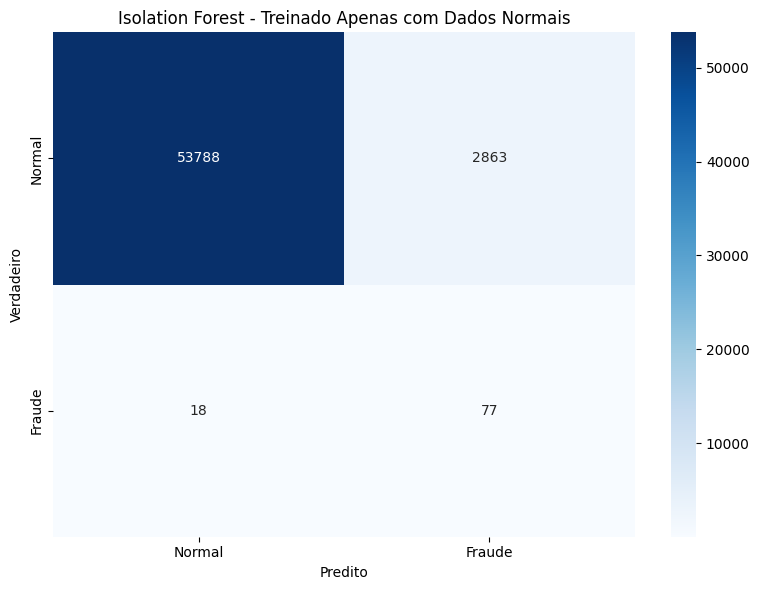

In [7]:
# Métricas de performance
print("RELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred_binary, target_names=['Normal', 'Fraude']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraude'], 
            yticklabels=['Normal', 'Fraude'])
plt.title('Isolation Forest - Treinado Apenas com Dados Normais')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

## Análise dos Scores de Anomalia

**Interpretação:**
- Scores **mais negativos** = maior probabilidade de anomalia
- Scores **mais positivos** = comportamento mais "normal"

/var/folders/34/zlczt9hd2mg95dmh1kfv96f40000gp/T/ipykernel_86553/264294561.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_for_box, labels=['Normal', 'Fraude'])


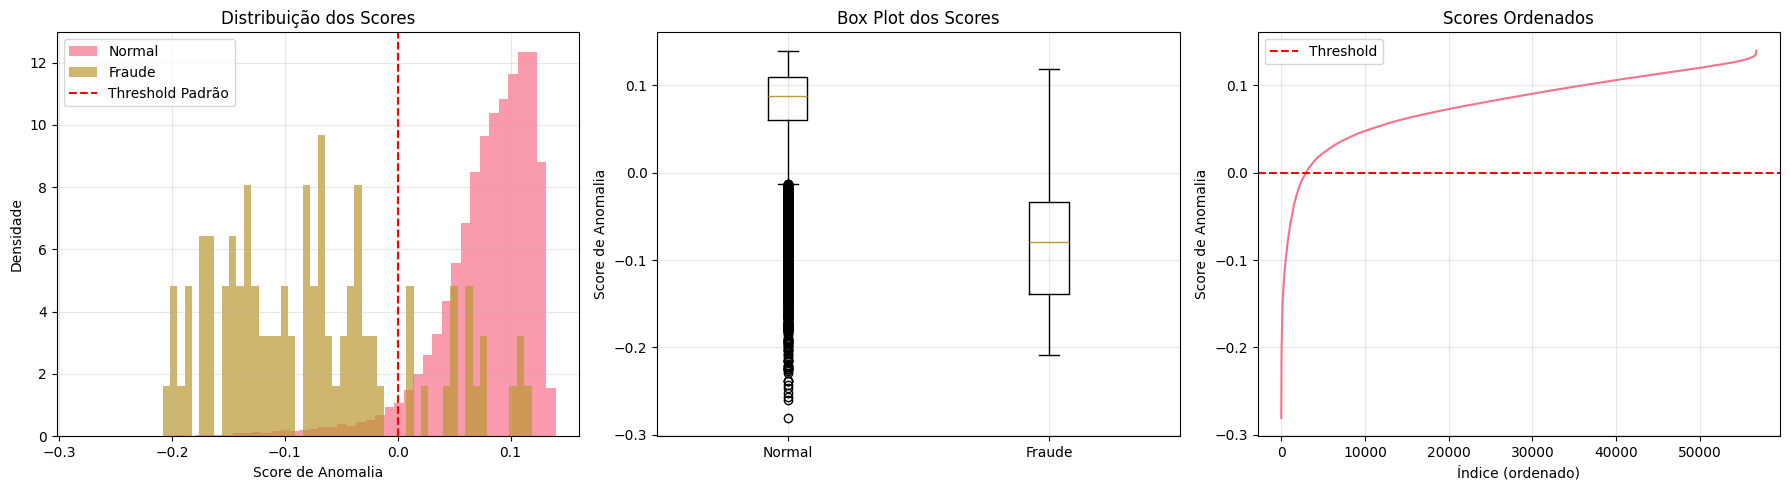

Score médio - Normais: 0.0788
Score médio - Fraudes: -0.0758
Separação: 0.1546


In [8]:
# Analisando distribuição dos scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuição dos scores por classe
axes[0].hist(anomaly_scores[y_test==0], bins=50, alpha=0.7, label='Normal', density=True)
axes[0].hist(anomaly_scores[y_test==1], bins=50, alpha=0.7, label='Fraude', density=True)
axes[0].axvline(0, color='red', linestyle='--', label='Threshold Padrão')
axes[0].set_xlabel('Score de Anomalia')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição dos Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Box plot dos scores
data_for_box = [
    anomaly_scores[y_test==0],
    anomaly_scores[y_test==1]
]
axes[1].boxplot(data_for_box, labels=['Normal', 'Fraude'])
axes[1].set_ylabel('Score de Anomalia')
axes[1].set_title('Box Plot dos Scores')
axes[1].grid(True, alpha=0.3)

# 3. Scores ordenados
sorted_scores = np.sort(anomaly_scores)
axes[2].plot(range(len(sorted_scores)), sorted_scores)
axes[2].axhline(0, color='red', linestyle='--', label='Threshold')
axes[2].set_xlabel('Índice (ordenado)')
axes[2].set_ylabel('Score de Anomalia')
axes[2].set_title('Scores Ordenados')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Score médio - Normais: {anomaly_scores[y_test==0].mean():.4f}")
print(f"Score médio - Fraudes: {anomaly_scores[y_test==1].mean():.4f}")
print(f"Separação: {anomaly_scores[y_test==0].mean() - anomaly_scores[y_test==1].mean():.4f}")

## Otimizando o Threshold

**Problema do threshold fixo:**
O Isolation Forest usa threshold=0 por padrão, mas podemos otimizar isso com base na curva ROC.

In [9]:
# Curva ROC para encontrar melhor threshold
fpr, tpr, thresholds = roc_curve(y_test, -anomaly_scores)  # Nota: -scores porque queremos scores baixos = anomalia
roc_auc = auc(fpr, tpr)

# Encontrando melhor threshold (máximo Youden's J)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds[optimal_idx]  # Convertendo de volta

print(f"AUC-ROC: {roc_auc:.4f}")
print(f"Threshold ótimo: {optimal_threshold:.4f}")
print(f"Threshold padrão: 0.0000")

# Aplicando threshold otimizado
y_pred_optimized = np.where(anomaly_scores < optimal_threshold, 1, 0)

print(f"\nDetecções com threshold padrão: {np.sum(y_pred_binary == 1)}")
print(f"Detecções com threshold ótimo: {np.sum(y_pred_optimized == 1)}")
print(f"Fraudes reais: {np.sum(y_test == 1)}")

AUC-ROC: 0.9293
Threshold ótimo: 0.0111
Threshold padrão: 0.0000

Detecções com threshold padrão: 2940
Detecções com threshold ótimo: 3748
Fraudes reais: 95


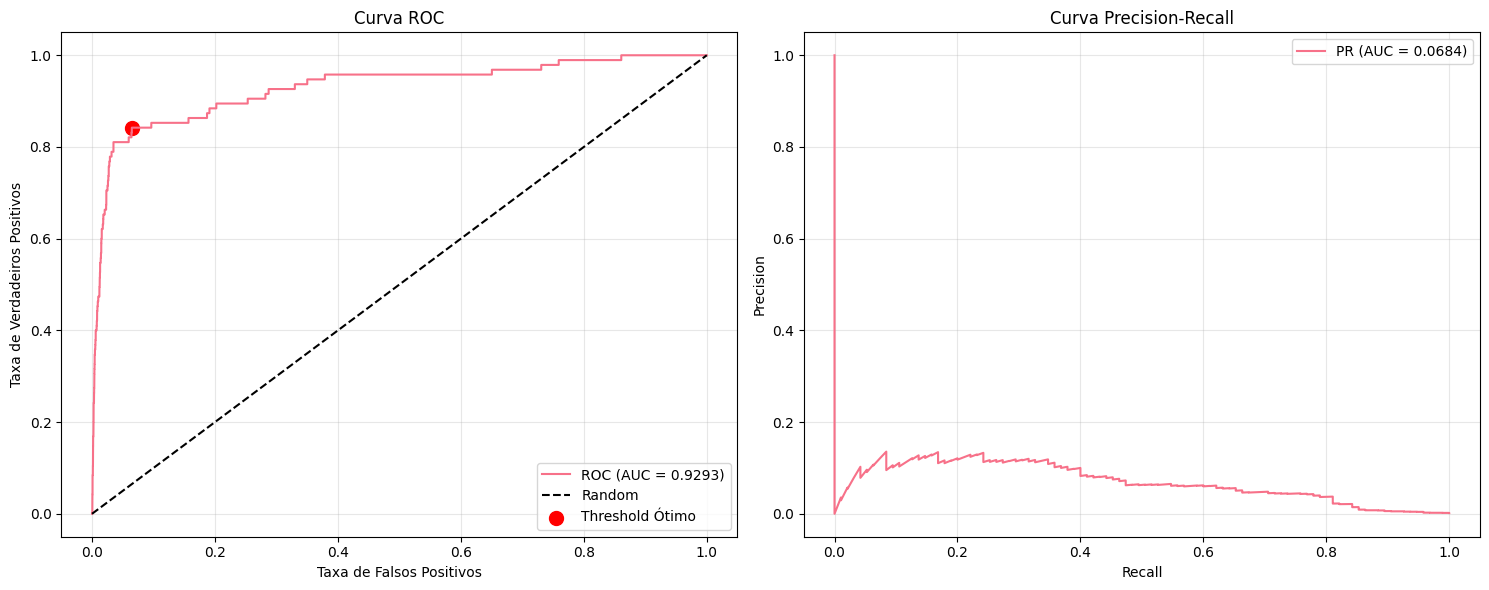

In [10]:
# Comparando resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Curva ROC
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, label='Threshold Ótimo')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(y_test, -anomaly_scores)
pr_auc = auc(recall, precision)

axes[1].plot(recall, precision, label=f'PR (AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# pesquisar mais sobre essas curvas

In [11]:
# Comparação final
print("COMPARAÇÃO: Threshold Padrão vs Otimizado")
print("="*50)
print("THRESHOLD PADRÃO (0.0):")
print(classification_report(y_test, y_pred_binary, target_names=['Normal', 'Fraude']))

print(f"\nTHRESHOLD OTIMIZADO ({optimal_threshold:.4f}):")
print(classification_report(y_test, y_pred_optimized, target_names=['Normal', 'Fraude']))

COMPARAÇÃO: Threshold Padrão vs Otimizado
THRESHOLD PADRÃO (0.0):
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56651
      Fraude       0.03      0.81      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.88      0.51     56746
weighted avg       1.00      0.95      0.97     56746


THRESHOLD OTIMIZADO (0.0111):
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97     56651
      Fraude       0.02      0.83      0.04        95

    accuracy                           0.94     56746
   macro avg       0.51      0.88      0.50     56746
weighted avg       1.00      0.94      0.96     56746



## Testando com Diferentes Contaminations

**Impacto do parâmetro contamination:**

In [12]:
# Testando diferentes valores de contamination
contaminations = [0.01, 0.05, 0.10, 0.15, 0.20]
results = []

for cont in contaminations:
    model = IsolationForest(contamination=cont, n_estimators=100, random_state=42)
    model.fit(X_train_normal)  # Sempre treinando apenas com dados normais
    
    pred = model.predict(X_test)
    scores = model.decision_function(X_test)
    pred_binary = np.where(pred == -1, 1, 0)
    
    # Calculando métricas
    tp = np.sum((y_test == 1) & (pred_binary == 1))
    fp = np.sum((y_test == 0) & (pred_binary == 1))
    fn = np.sum((y_test == 1) & (pred_binary == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results.append({
        'contamination': cont,
        'detectadas': np.sum(pred == -1),
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'scores_mean_fraud': scores[y_test==1].mean(),
        'scores_mean_normal': scores[y_test==0].mean()
    })

df_results = pd.DataFrame(results)
print("RESULTADOS POR CONTAMINATION:")
print(df_results.round(4))

RESULTADOS POR CONTAMINATION:
   contamination  detectadas  precision  recall  f1_score  scores_mean_fraud  \
0           0.01         662     0.0680  0.4737    0.1189             0.0116   
1           0.05        2940     0.0262  0.8105    0.0507            -0.0758   
2           0.10        5857     0.0138  0.8526    0.0272            -0.1043   
3           0.15        8643     0.0094  0.8526    0.0185            -0.1186   
4           0.20       11444     0.0073  0.8842    0.0146            -0.1284   

   scores_mean_normal  
0              0.1662  
1              0.0788  
2              0.0503  
3              0.0360  
4              0.0262  


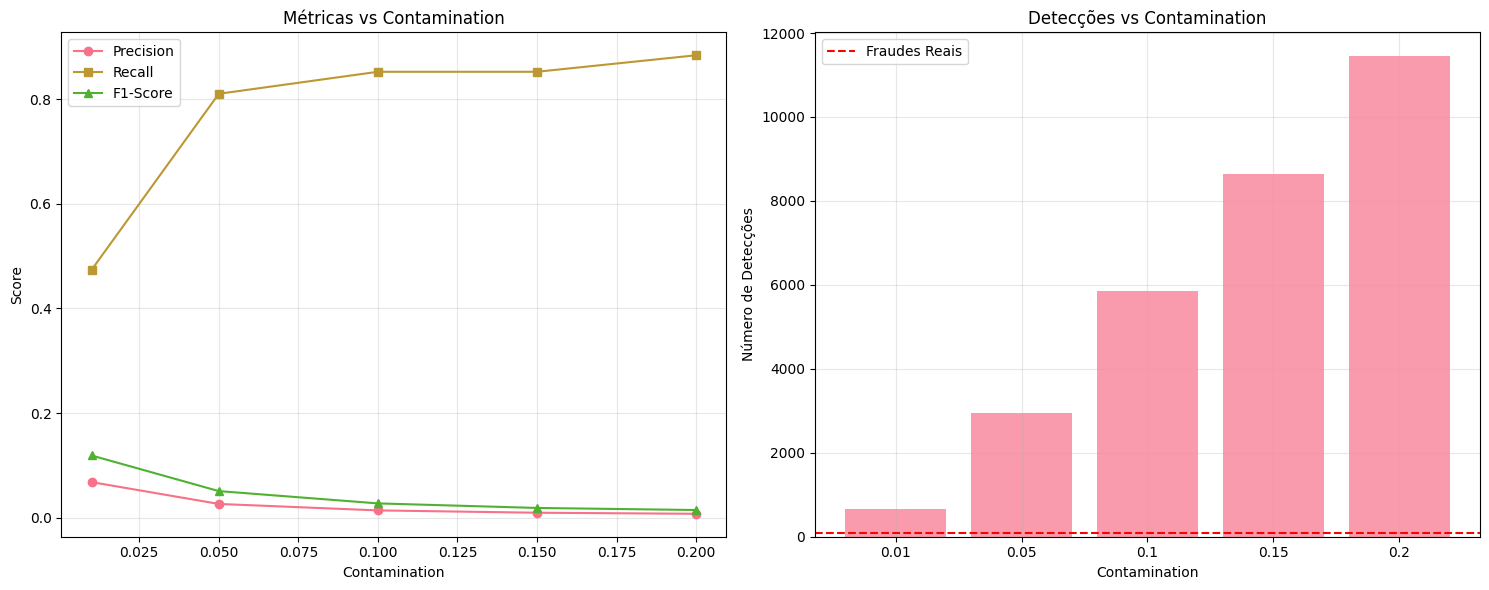


🎯 Melhor contamination: 0.01 (F1-Score: 0.1189)


In [13]:
# Visualizando impacto do contamination
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Métricas por contamination
axes[0].plot(df_results['contamination'], df_results['precision'], 'o-', label='Precision')
axes[0].plot(df_results['contamination'], df_results['recall'], 's-', label='Recall')
axes[0].plot(df_results['contamination'], df_results['f1_score'], '^-', label='F1-Score')
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel('Score')
axes[0].set_title('Métricas vs Contamination')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Número de detecções
axes[1].bar(range(len(contaminations)), df_results['detectadas'], alpha=0.7)
axes[1].axhline(y=np.sum(y_test == 1), color='red', linestyle='--', label='Fraudes Reais')
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('Número de Detecções')
axes[1].set_title('Detecções vs Contamination')
axes[1].set_xticks(range(len(contaminations)))
axes[1].set_xticklabels(contaminations)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Melhor contamination
best_idx = df_results['f1_score'].idxmax()
best_contamination = df_results.loc[best_idx, 'contamination']
best_f1 = df_results.loc[best_idx, 'f1_score']
print(f"\n🎯 Melhor contamination: {best_contamination} (F1-Score: {best_f1:.4f})")

## Conclusões sobre Isolation Forest

### ✅ **Quando usar Isolation Forest:**
1. **Detecção não supervisionada de anomalias**
2. **Quando você tem POUCOS ou NENHUM exemplo de anomalias**
3. **Dados com muitas dimensões**
4. **Quando não consegue rotular anomalias facilmente**

### ❌ **Quando NÃO usar:**
1. **Problemas de classificação supervisionada** (use XGBoost, Random Forest, etc.)
2. **Quando você tem muitos exemplos rotulados de ambas as classes**
3. **Quando precisa de alta precisão em dados muito desbalanceados**

### 🎯 **Principais insights:**
- **Treinar apenas com dados normais** é a abordagem correta
- **Contamination** é o parâmetro mais importante para ajustar
- **Threshold otimizado** pode melhorar significativamente os resultados
- **AUC-ROC é melhor métrica** que F1-Score para este tipo de problema

### 🔧 **Para melhorar ainda mais:**
1. **Feature engineering** específica para detectar padrões anômalos
2. **Ensemble** com outros algoritmos de detecção de anomalias
3. **Validação temporal** se os dados têm componente temporal
4. **Extended Isolation Forest** para melhor performance